# Train Decision Tree Model

## Motivation
A **Decision Tree** was chosen for this alarm-prediction task for three reasons:

1. **Non-linearity** — alarm patterns are driven by complex threshold combinations (e.g. `alarm_status_1h_ago == 1 AND alarms_count_1h_ago > 5`). Linear models struggle to capture these; a tree splits on exactly such boundaries natively.
2. **Mixed feature types** — the dataset has numeric weather/NLP features alongside binary categorical flags. Decision Trees handle both without requiring standardisation or encoding, making the pipeline simpler and easier to interpret.
3. **Interpretability & feature importance** — trees provide native `feature_importances_` (Gini impurity reduction), giving a direct and meaningful ranking of the 102 features with no extra computation. This is a key task requirement.

> Note: unlike Linear Regression, Decision Trees do **not** require feature scaling. The `StandardScaler` step is deliberately removed from the pipeline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from pathlib import Path
from time import time

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    average_precision_score, matthews_corrcoef, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

import os
os.chdir("../../Samoobuchenie/GoIt")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Loading dataset

In [8]:
data_path = Path("DS_lab/data/merged_preprocessed.csv")

df = pd.read_csv(data_path)

df.head()

,region_id,time,alarm,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,region_city,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,day_of_week,is_weekend,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,anomaly_count_7d,avg_dist_centroid_7d,news_count_7d,topic_entropy_7d,topic_entropy_30d,news_velocity_30d,news_velocity_7d,centroid_shift_7d,avg_dist_centroid_30d,dom_cluster_share_7d,anomaly_count_30d,centroid_shift_30d,news_count_30d,dom_cluster_share_30d,year,month,day,hour,hops_to_nearest_alarm,alarms_count_1h_ago,alarms_count_2h_ago,alarms_count_3h_ago,alarms_count_4h_ago,alarms_count_5h_ago,alarms_count_6h_ago,alarms_count_7h_ago,alarms_count_8h_ago,alarms_count_9h_ago,alarms_count_10h_ago,alarms_count_11h_ago,alarms_count_12h_ago,alarm_status_1h_ago,alarm_status_2h_ago,alarm_status_3h_ago,alarm_status_4h_ago,alarm_status_5h_ago,alarm_status_6h_ago,alarm_status_7h_ago,alarm_status_8h_ago,alarm_status_9h_ago,alarm_status_10h_ago,alarm_status_11h_ago,alarm_status_12h_ago,alarm_status_13h_ago,alarm_status_14h_ago,alarm_status_15h_ago,alarm_status_16h_ago,alarm_status_17h_ago,alarm_status_18h_ago,alarm_status_19h_ago,alarm_status_20h_ago,alarm_status_21h_ago,alarm_status_22h_ago,alarm_status_23h_ago,alarm_status_24h_ago
0,1,2022-03-29 00:00:00+03:00,0,11.6,11.6,27.80,-6.4,0.0,0.0,0,13.9,257.0,1016.0,20.0,0.0,0.0,0,21,13,0,0,0,8,8,0,0,0,0,0,0,0,0,2,8,0,51,337,-12,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,0,1.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,16.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2022-03-29 01:00:00+03:00,0,11.0,11.0,29.92,-6.0,0.0,0.0,0,9.5,256.0,1015.8,20.0,20.7,0.0,4,21,6,1,0,0,4,4,0,0,2,0,0,0,1,1,2,4,0,41,335,1,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,1,1.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,2022-03-29 02:00:00+03:00,0,10.3,10.3,32.92,-5.3,0.0,0.0,0,12.3,240.0,1015.3,20.0,30.6,0.0,4,21,1,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,20,329,0,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,2,1.0,4.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,2022-03-29 03:00:00+03:00,1,9.6,7.8,34.71,-5.3,0.0,0.0,0,12.3,241.0,1014.9,20.0,0.0,0.0,0,21,32,26,0,0,4,4,2,0,4,0,0,0,26,26,26,4,2,39,350,25,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,3,3.0,1.0,4.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,2022-03-29 04:00:00+03:00,1,8.5,7.1,36.42,-5.6,0.0,0.0,0,8.6,217.0,1014.3,20.0,0.0,0.0,0,21,24,2,0,0,21,21,2,0,0,0,0,0,2,2,4,21,4,57,365,-24,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,4,0.0,21.0,1.0,4.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 804537 entries, 0 to 804536
Columns: 106 entries, region_id to alarm_status_24h_ago
dtypes: float64(57), int64(48), str(1)
memory usage: 650.6 MB


# Time feature engineering

In [10]:
df["time"] = pd.to_datetime(df["time"], utc=True)

df.head()

,region_id,time,alarm,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,region_city,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,day_of_week,is_weekend,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,anomaly_count_7d,avg_dist_centroid_7d,news_count_7d,topic_entropy_7d,topic_entropy_30d,news_velocity_30d,news_velocity_7d,centroid_shift_7d,avg_dist_centroid_30d,dom_cluster_share_7d,anomaly_count_30d,centroid_shift_30d,news_count_30d,dom_cluster_share_30d,year,month,day,hour,hops_to_nearest_alarm,alarms_count_1h_ago,alarms_count_2h_ago,alarms_count_3h_ago,alarms_count_4h_ago,alarms_count_5h_ago,alarms_count_6h_ago,alarms_count_7h_ago,alarms_count_8h_ago,alarms_count_9h_ago,alarms_count_10h_ago,alarms_count_11h_ago,alarms_count_12h_ago,alarm_status_1h_ago,alarm_status_2h_ago,alarm_status_3h_ago,alarm_status_4h_ago,alarm_status_5h_ago,alarm_status_6h_ago,alarm_status_7h_ago,alarm_status_8h_ago,alarm_status_9h_ago,alarm_status_10h_ago,alarm_status_11h_ago,alarm_status_12h_ago,alarm_status_13h_ago,alarm_status_14h_ago,alarm_status_15h_ago,alarm_status_16h_ago,alarm_status_17h_ago,alarm_status_18h_ago,alarm_status_19h_ago,alarm_status_20h_ago,alarm_status_21h_ago,alarm_status_22h_ago,alarm_status_23h_ago,alarm_status_24h_ago
0,1,2022-03-28 21:00:00+00:00,0,11.6,11.6,27.80,-6.4,0.0,0.0,0,13.9,257.0,1016.0,20.0,0.0,0.0,0,21,13,0,0,0,8,8,0,0,0,0,0,0,0,0,2,8,0,51,337,-12,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,0,1.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,16.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2022-03-28 22:00:00+00:00,0,11.0,11.0,29.92,-6.0,0.0,0.0,0,9.5,256.0,1015.8,20.0,20.7,0.0,4,21,6,1,0,0,4,4,0,0,2,0,0,0,1,1,2,4,0,41,335,1,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,1,1.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,2022-03-28 23:00:00+00:00,0,10.3,10.3,32.92,-5.3,0.0,0.0,0,12.3,240.0,1015.3,20.0,30.6,0.0,4,21,1,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,20,329,0,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,2,1.0,4.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,2022-03-29 00:00:00+00:00,1,9.6,7.8,34.71,-5.3,0.0,0.0,0,12.3,241.0,1014.9,20.0,0.0,0.0,0,21,32,26,0,0,4,4,2,0,4,0,0,0,26,26,26,4,2,39,350,25,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,3,3.0,1.0,4.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,2022-03-29 01:00:00+00:00,1,8.5,7.1,36.42,-5.6,0.0,0.0,0,8.6,217.0,1014.3,20.0,0.0,0.0,0,21,24,2,0,0,21,21,2,0,0,0,0,0,2,2,4,21,4,57,365,-24,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,4,0.0,21.0,1.0,4.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
print(f"Percent of alarms: {df['alarm'].sum() / len(df):.2%}")

Percent of alarms: 20.80%


# Target and features

In [12]:
target = "alarm"

NON_FEATURES = {"alarm", "time", "region_id", "region_city"}

features = [c for c in df.columns if c not in NON_FEATURES]

X = df.copy()
y = X.pop(target)

print("Number of model features:", len(features))

Number of model features: 102


# Feature groups

In [13]:
cat_cols = [
    "hour_preciptype",
    "hour_conditions",
    "is_weekend",
    "day_of_week",
]

num_cols = [
    col for col in features
    if col not in cat_cols
]

print("Numeric :", len(num_cols))
print("Categorical:", len(cat_cols))

Numeric : 98
Categorical: 4


# Model pipeline
Decision Trees are **invariant to feature scaling** — splits are based on rank order, not magnitude.  
Therefore no `StandardScaler` is applied; all features pass through unchanged.

In [19]:
model = Pipeline([
    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42
    ))
])

## Cross-validation with `evaluate_model`

Same time-series cross-validation strategy as in the Linear Regression notebook.

Key adaptation for Decision Tree:
- Uses `predict_proba()[:, 1]` for AUPRC (probabilistic ranking), keeping hard `predict()` for F1 and MCC.

In [20]:
def evaluate_model(pipeline, X=X, y=y, n_splits: int = 5, gap: int = 24 * 7):
    fold_train_f1 = [[] for _ in range(n_splits)]
    fold_test_f1  = [[] for _ in range(n_splits)]
    fold_auprc    = [[] for _ in range(n_splits)]
    fold_mcc      = [[] for _ in range(n_splits)]

    all_y_true = []
    all_y_pred = []

    regions = sorted(X["region_id"].unique())
    t0 = time()

    for region_id in regions:
        mask_region = X["region_id"] == region_id
        unique_hours = X.loc[mask_region, "time"].sort_values().unique()
        tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)

        for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_hours)):
            train_hours = unique_hours[train_idx]
            test_hours  = unique_hours[test_idx]

            train_mask = X["time"].isin(train_hours) & mask_region
            test_mask  = X["time"].isin(test_hours)  & mask_region

            drop_cols = ["time", "region_id"]
            X_train = X[train_mask].drop(columns=drop_cols)
            X_test  = X[test_mask].drop(columns=drop_cols)
            y_train = y[train_mask]
            y_test  = y[test_mask]

            if len(X_test) == 0:
                print(f"  [warning] Empty test set — fold {fold}, region {region_id}")
                continue

            pipeline.fit(X_train, y_train)

            y_pred_train    = pipeline.predict(X_train)
            y_pred_test     = pipeline.predict(X_test)
            pred_test_proba = pipeline.predict_proba(X_test)[:, 1]   # probabilities for AUPRC

            y_train_cls = (y_train > 0).astype(int)
            y_test_cls  = (y_test  > 0).astype(int)

            fold_train_f1[fold].append(f1_score(y_train_cls, y_pred_train,    zero_division=0))
            fold_test_f1[fold].append( f1_score(y_test_cls,  y_pred_test,     zero_division=0))
            fold_auprc[fold].append(   average_precision_score(y_test_cls, pred_test_proba))
            fold_mcc[fold].append(     matthews_corrcoef(y_test_cls, y_pred_test))

            all_y_true.extend(y_test_cls)
            all_y_pred.extend(y_pred_test)

    train_f1_m = [np.mean(s) for s in fold_train_f1 if s]
    test_f1_m  = [np.mean(s) for s in fold_test_f1  if s]
    auprc_m    = [np.mean(s) for s in fold_auprc     if s]
    mcc_m      = [np.mean(s) for s in fold_mcc       if s]

    print("\n-------- Per-Fold Results (mean across regions) --------")
    for i, (tr, te, ap, mc) in enumerate(zip(train_f1_m, test_f1_m, auprc_m, mcc_m)):
        print(f"  Fold {i+1}  Train F1: {tr:.3f}  Test F1: {te:.3f}  AUPRC: {ap:.3f}  MCC: {mc:.3f}")

    print("\n-------- Overall --------")
    print(f"Train F1 : {np.mean(train_f1_m):.3f} ± {np.std(train_f1_m):.3f}")
    print(f"Test  F1 : {np.mean(test_f1_m):.3f} ± {np.std(test_f1_m):.3f}")
    print(f"AUPRC    : {np.mean(auprc_m):.3f} ± {np.std(auprc_m):.3f}")
    print(f"MCC      : {np.mean(mcc_m):.3f} ± {np.std(mcc_m):.3f}")
    print(f"Completed in: {time() - t0:.2f}s")

    scores = {
        "train_f1": train_f1_m,
        "test_f1":  test_f1_m,
        "auprc":    auprc_m,
        "mcc":      mcc_m,
    }
    overall_cm = confusion_matrix(all_y_true, all_y_pred)
    return scores, overall_cm

In [21]:
scores, cm = evaluate_model(model)


-------- Per-Fold Results (mean across regions) --------
  Fold 1  Train F1: 0.717  Test F1: 0.619  AUPRC: 0.836  MCC: 0.611
  Fold 2  Train F1: 0.746  Test F1: 0.723  AUPRC: 0.864  MCC: 0.688
  Fold 3  Train F1: 0.751  Test F1: 0.680  AUPRC: 0.846  MCC: 0.616
  Fold 4  Train F1: 0.770  Test F1: 0.638  AUPRC: 0.819  MCC: 0.571
  Fold 5  Train F1: 0.770  Test F1: 0.543  AUPRC: 0.614  MCC: 0.425

-------- Overall --------
Train F1 : 0.751 ± 0.020
Test  F1 : 0.641 ± 0.060
AUPRC    : 0.796 ± 0.092
MCC      : 0.582 ± 0.087
Completed in: 39.44s


## Confusion Matrix — Baseline Decision Tree

**What the metrics mean:**

| Cell | Meaning |
|------|----------|
| **True Negative (TN)** | Model correctly predicted *no alarm* — safe hour correctly identified |
| **False Positive (FP)** | Model predicted *alarm* but there was none — unnecessary alert (costs attention) |
| **False Negative (FN)** | Model predicted *no alarm* but an alarm occurred — **missed threat** (most dangerous) |
| **True Positive (TP)** | Model correctly predicted an *alarm* — correct warning issued |

For this domain (air-raid alarm prediction), **False Negatives are the most costly** — a missed alarm means no warning for civilians. The model should therefore prioritise high Recall over Precision.

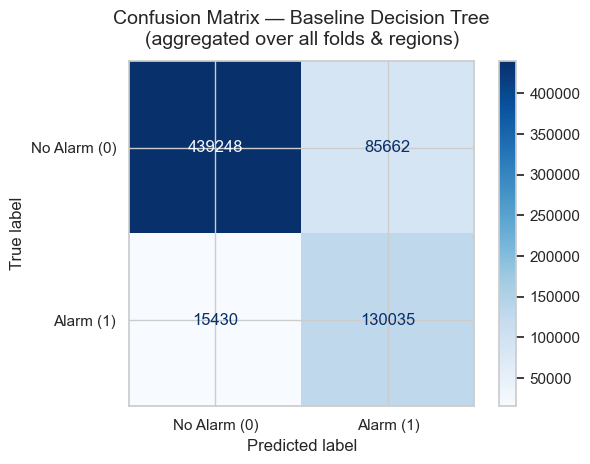

In [22]:
disp = ConfusionMatrixDisplay(
    cm,
    display_labels=["No Alarm (0)", "Alarm (1)"]
)
disp.plot(cmap="Blues")
plt.title(
    "Confusion Matrix — Baseline Decision Tree\n(aggregated over all folds & regions)",
    fontsize=14, pad=12
)
plt.tight_layout()
plt.show()

# Hyperparameter Tuning — GridSearchCV

## Scoring metrics chosen

| Metric | Why used |
|--------|----------|
| **`f1`** | Matches `evaluate_model` — balances Precision and Recall for the imbalanced 20/80 alarm/no-alarm split |
| **`average_precision`** | Best complement for imbalanced binary classification — AUPRC summarises Precision-Recall trade-off across all thresholds without being skewed by the large TN count (unlike ROC-AUC) |

**Refit metric:** `f1` (consistent with how `evaluate_model` evaluates all models in this project).

## Parameters searched

| Parameter | Values | Reasoning |
|-----------|--------|------------|
| `criterion` | `gini`, `entropy` | Gini is faster; entropy often finds better splits on imbalanced data |
| `max_depth` | `5, 10, 20, 30, None` | Controls overfitting — unlimited depth on 800k rows will memorise training data |
| `min_samples_split` | `2, 20, 100, 500` | Minimum samples to attempt a split — larger values regularise |
| `min_samples_leaf` | `1, 20, 100` | Minimum samples in any leaf — prevents tiny noisy leaves |
| `max_features` | `None, sqrt, log2` | Feature subsetting per split — introduces randomness similar to Random Forest |
| `class_weight` | `None, balanced` | `balanced` upweights the minority alarm class — important at 20% positive rate |

> ⚠️ **Runtime note:** this grid has 2 × 5 × 4 × 3 × 3 × 2 = **720 combinations**.  
> With `cv=3` TimeSeriesSplit that is **2160 fits** on a large dataset.  
> Expect this cell to run for **several hours** on the full 800k-row dataset.  
> To prototype quickly, replace `X` with a sampled subset (e.g. `df.sample(frac=0.2, random_state=42)`).

In [36]:
tscv_gs = TimeSeriesSplit(n_splits=3, gap=24 * 7)

param_grid = {
    "classifier__criterion":         ["gini", "entropy"],
    "classifier__max_depth":         [5, 10, 20],
    "classifier__min_samples_split": [20, 100],
    "classifier__min_samples_leaf":  [20, 100],
    "classifier__max_features":      ["sqrt", "log2"],
    "classifier__class_weight":      ["balanced"],
}

X_gs = X.drop(columns=["time", "region_id"])

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring={"f1": "f1", "average_precision": "average_precision"},
    refit="f1",
    cv=tscv_gs,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
)

t0 = time()
grid_search.fit(X_gs, y)
print(f"\nGridSearchCV completed in: {time() - t0:.2f}s")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV] END classifier__class_weight=balanced, classifier__criterion=gini, classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_leaf=20, classifier__min_samples_split=100; total time=   5.7s
[CV] END classifier__class_weight=balanced, classifier__criterion=gini, classifier__max_depth=5, classifier__max_features=log2, classifier__min_samples_leaf=20, classifier__min_samples_split=20; total time=   6.4s
[CV] END classifier__class_weight=balanced, classifier__criterion=gini, classifier__max_depth=10, classifier__max_features=sqrt, classifier__min_samples_leaf=20, classifier__min_samples_split=20; total time=   7.5s
[CV] END classifier__class_weight=balanced, classifier__criterion=gini, classifier__max_depth=10, classifier__max_features=log2, classifier__min_samples_leaf=20, classifier__min_samples_split=20; total time=   6.2s
[CV] END classifier__class_weight=balanced, classifier__criterion=gini, classif

In [41]:
print("Best parameters:")
for param, val in grid_search.best_params_.items():
    print(f"  {param}: {val}")

print(f"\nBest CV F1       : {grid_search.best_score_:.4f}")
print(f"Best CV AUPRC    : {grid_search.cv_results_['mean_test_average_precision'][grid_search.best_index_]:.4f}")

Best parameters:
  classifier__class_weight: balanced
  classifier__criterion: entropy
  classifier__max_depth: 20
  classifier__max_features: sqrt
  classifier__min_samples_leaf: 20
  classifier__min_samples_split: 20

Best CV F1       : 0.7350
Best CV AUPRC    : 0.7972


In [42]:
cv_results = pd.DataFrame(grid_search.cv_results_)

top10 = (
    cv_results
    .sort_values("mean_test_f1", ascending=False)
    .head(10)
    [[
        "param_classifier__criterion",
        "param_classifier__max_depth",
        "param_classifier__min_samples_split",
        "param_classifier__min_samples_leaf",
        "param_classifier__max_features",
        "param_classifier__class_weight",
        "mean_test_f1",
        "mean_test_average_precision",
    ]]
    .rename(columns=lambda c: c.replace("param_classifier__", "").replace("mean_test_", ""))
    .reset_index(drop=True)
)

top10

,criterion,max_depth,min_samples_split,min_samples_leaf,max_features,class_weight,f1,average_precision
0,entropy,20,20,20,sqrt,balanced,0.735039,0.797212
1,gini,10,100,20,sqrt,balanced,0.732159,0.802659
2,gini,20,100,20,sqrt,balanced,0.730645,0.810341
3,gini,20,20,20,sqrt,balanced,0.729218,0.790650
4,gini,10,20,20,sqrt,balanced,0.728573,0.805089
5,entropy,20,100,20,sqrt,balanced,0.726885,0.801016
6,gini,20,100,100,sqrt,balanced,0.725026,0.808997
7,gini,20,20,100,sqrt,balanced,0.725026,0.808997
8,entropy,10,20,20,sqrt,balanced,0.722885,0.807032
9,entropy,10,100,20,sqrt,balanced,0.721158,0.790406


# Tuned model — full evaluation

In [40]:
# best_estimator_ is already refitted on the full dataset by GridSearchCV
tuned_model = model #grid_search.best_estimator_

scores_tuned, cm_tuned = evaluate_model(tuned_model)


-------- Per-Fold Results (mean across regions) --------
  Fold 1  Train F1: 0.717  Test F1: 0.619  AUPRC: 0.836  MCC: 0.611
  Fold 2  Train F1: 0.746  Test F1: 0.723  AUPRC: 0.864  MCC: 0.688
  Fold 3  Train F1: 0.751  Test F1: 0.680  AUPRC: 0.846  MCC: 0.616
  Fold 4  Train F1: 0.770  Test F1: 0.638  AUPRC: 0.819  MCC: 0.571
  Fold 5  Train F1: 0.770  Test F1: 0.543  AUPRC: 0.614  MCC: 0.425

-------- Overall --------
Train F1 : 0.751 ± 0.020
Test  F1 : 0.641 ± 0.060
AUPRC    : 0.796 ± 0.092
MCC      : 0.582 ± 0.087
Completed in: 39.25s


## Confusion Matrix — Tuned Decision Tree

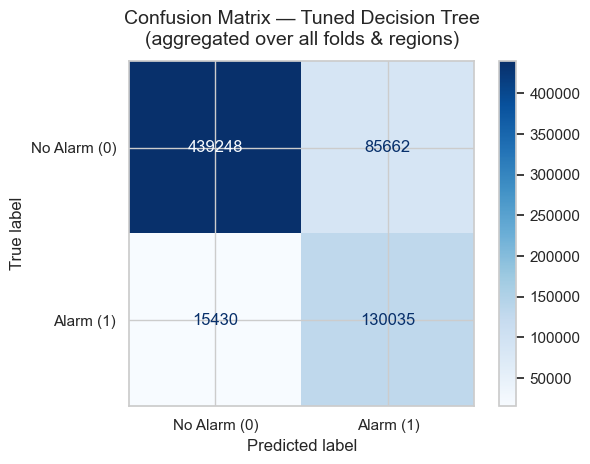

In [43]:
disp_tuned = ConfusionMatrixDisplay(
    cm_tuned,
    display_labels=["No Alarm (0)", "Alarm (1)"]
)
disp_tuned.plot(cmap="Blues")
plt.title(
    "Confusion Matrix — Tuned Decision Tree\n(aggregated over all folds & regions)",
    fontsize=14, pad=12
)
plt.tight_layout()
plt.show()

# Save model as pickle

In [44]:
model_path = Path("/app/models/Decision_Tree_v1.pkl")

with open(model_path, "wb") as f:
    pickle.dump(tuned_model, f)

print(f"Model saved → {model_path.resolve()}")

Model saved → /Users/eugene_kuj/PycharmProjects/DS_lab/app/models/Decision_Tree_v1.pkl


# Top 20 features and weights

Decision Tree uses **Gini impurity reduction** (`feature_importances_`) as the feature weight.  
This measures how much each feature reduces impurity (uncertainty) across all splits in the tree, weighted by the number of samples reaching each split.  
Values sum to 1.0; higher = more important.

In [45]:
# The tuned pipeline has no preprocessor step — features map directly
feature_names = X.drop(columns=["time", "region_id"]).columns.tolist()

importances = tuned_model.named_steps["classifier"].feature_importances_

feat_imp = (
    pd.DataFrame({"feature": feature_names, "weight": importances})
    .sort_values("weight", ascending=False)
    .reset_index(drop=True)
)

top20 = feat_imp.head(20)
top20

,feature,weight
0,messages_count,0.642745
1,alarm_status_1h_ago,0.197099
2,alarms_count_1h_ago,0.046085
3,nlp_повітряна,0.024084
4,nlp_повітряна_тривога,0.012289
5,year,0.012006
6,nlp_дніпропетровська,0.008735
7,msg_count_last_3h,0.006615
8,nlp_бпла,0.006363
9,news_count_30d,0.005523


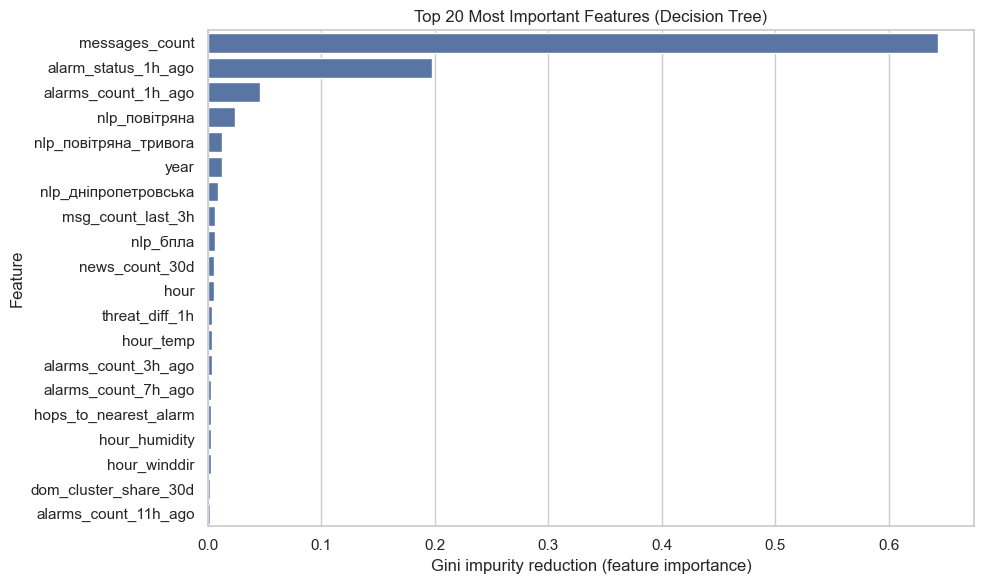

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top20,
    x="weight",
    y="feature"
)

plt.title("Top 20 Most Important Features (Decision Tree)")
plt.xlabel("Gini impurity reduction (feature importance)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()